In [ ]:
!pip install cloud-volume hypernetx dask networkx meshio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.3/234.3 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.4/591.4 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.2/166.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 

In [ ]:
!pip install numpy scipy matplotlib

In [ ]:
import numpy as np
import scipy
import networkx as nx
import hypernetx as hnx
import dask
import matplotlib.pyplot as plt
from cloudvolume import CloudVolume

print("All libraries loaded successfully!")

All libraries loaded successfully!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import pandas as pd

# Load the somas table directly - this is a small CSV, totally safe for laptop
url = "https://h01-release.storage.googleapis.com/data/20210601/c3/tables/somas.csv"

somas = pd.read_csv(url)
print(somas.shape)
print(somas.head())

(49379, 12)
   soma_id  base_seg_id  c2_rep_strict  c2_rep_manual  c3_rep_strict  \
0     8755  40447954335   5.088565e+09   5.088565e+09   3.162647e+10   
1     4282  41462519568   5.942899e+09   5.942899e+09   5.942899e+09   
2    46462  51931523143   4.303699e+10   4.303699e+10   4.309531e+10   
3    35642  36112523866   2.730545e+10   2.730545e+10   2.717439e+10   
4    22725  45369118861   1.944288e+10   1.944288e+10   2.747821e+10   

   c3_rep_manual  proofread_104_rep       x       y     z        celltype  \
0    31626468583                NaN  297143  186549  2304       PYRAMIDAL   
1     5942899024                NaN  164604  217431  2176  SPINY_STELLATE   
2    43095305030                NaN  235543  265551  2432           OLIGO   
3    27174390767                NaN  374081   56949  2304       ASTROCYTE   
4    27478208288                NaN  321717   68209  3968       PYRAMIDAL   

          layer  
0       Layer 4  
1  White matter  
2       Layer 6  
3       Layer 1  
4 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


celltype
OLIGO                  20139
PYRAMIDAL               8803
MG_OPC                  6536
ASTROCYTE               5474
INTERNEURON             4688
SPINY_ATYPICAL          1535
UNCLASSIFIED_NEURON      868
UNKNOWN                  692
BLOOD_VESSEL_CELL        285
SPINY_STELLATE           193
C_SHAPED                 166
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


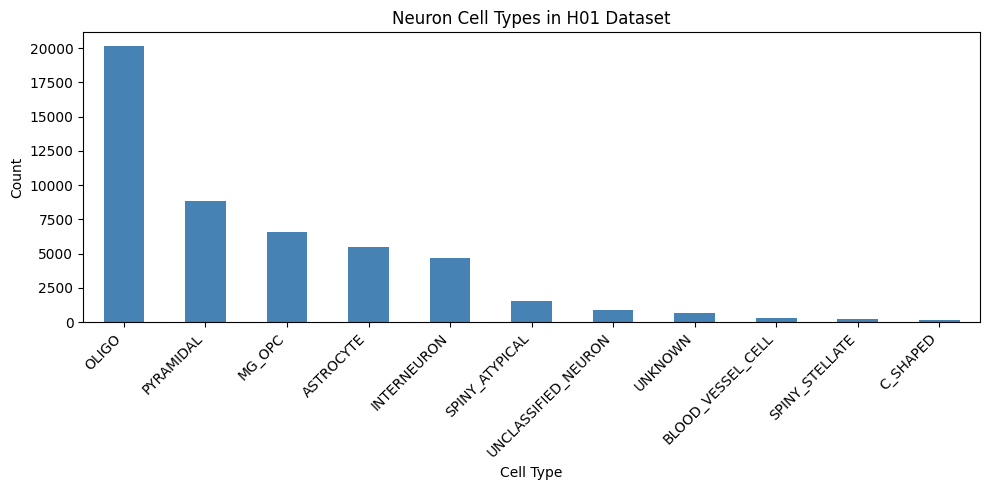

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import matplotlib.pyplot as plt

# Count cell types
celltype_counts = somas['celltype'].value_counts()
print(celltype_counts)

# Plot it
plt.figure(figsize=(10, 5))
celltype_counts.plot(kind='bar', color='steelblue')
plt.title('Neuron Cell Types in H01 Dataset')
plt.xlabel('Cell Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Filter to just excitatory (Pyramidal) and inhibitory (Interneuron) neurons
neurons = somas[somas['celltype'].isin(['PYRAMIDAL', 'INTERNEURON'])].copy()

print(f"Pyramidal neurons: {len(neurons[neurons['celltype'] == 'PYRAMIDAL'])}")
print(f"Interneurons: {len(neurons[neurons['celltype'] == 'INTERNEURON'])}")
print(f"Total: {len(neurons)}")

# Look at their layer distribution
layer_celtype = neurons.groupby(['layer', 'celltype']).size().unstack(fill_value=0)
print("\nNeurons per layer:")
print(layer_celtype)

Pyramidal neurons: 8803
Interneurons: 4688
Total: 13491

Neurons per layer:
celltype      INTERNEURON  PYRAMIDAL
layer                               
Layer 1               586         72
Layer 2              1594       2641
Layer 3               965       1569
Layer 4               688       2193
Layer 5               505       1206
Layer 6               128        621
White matter          111        301
unclassified           89        180


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


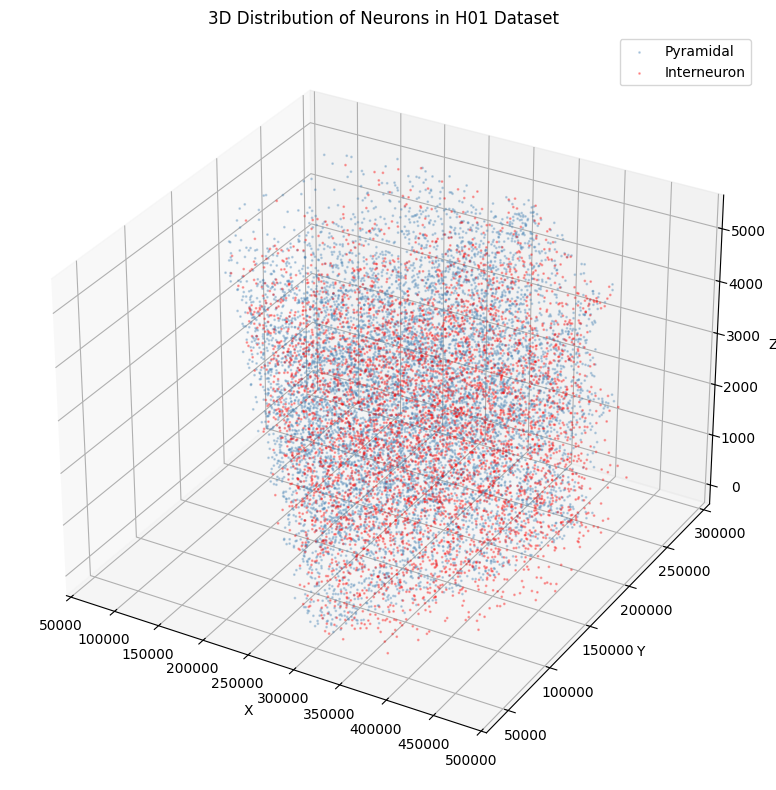

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot Pyramidal neurons in blue
pyr = neurons[neurons['celltype'] == 'PYRAMIDAL']
ax.scatter(pyr['x'], pyr['y'], pyr['z'],
           c='steelblue', s=1, alpha=0.3, label='Pyramidal')

# Plot Interneurons in red
inter = neurons[neurons['celltype'] == 'INTERNEURON']
ax.scatter(inter['x'], inter['y'], inter['z'],
           c='red', s=1, alpha=0.3, label='Interneuron')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Distribution of Neurons in H01 Dataset')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Let's zoom into a small cube of the data
# Pick the middle of the dataset as our region of interest
x_mid = neurons['x'].median()
y_mid = neurons['y'].median()
z_mid = neurons['z'].median()

# Define a small patch (adjust size if too few/many neurons)
patch_size = 50000  # in nanometers (~50 microns)

patch = neurons[
    (neurons['x'].between(x_mid - patch_size, x_mid + patch_size)) &
    (neurons['y'].between(y_mid - patch_size, y_mid + patch_size)) &
    (neurons['z'].between(z_mid - patch_size, z_mid + patch_size))
]

print(f"Neurons in patch: {len(patch)}")
print(patch['celltype'].value_counts())
print(patch['layer'].value_counts())

Neurons in patch: 2618
celltype
PYRAMIDAL      1766
INTERNEURON     852
Name: count, dtype: int64
layer
Layer 3    1200
Layer 4    1057
Layer 2     266
Layer 5      89
Layer 1       3
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import hypernetx as hnx
import numpy as np

# Reset index for easy referencing
patch = patch.reset_index(drop=True)

# Build hyperedges based on spatial proximity
# Each Pyramidal neuron = one hyperedge containing nearby Interneurons
# This represents the "broadcast domain" from your research plan

hyperedges = {}
pyramidal = patch[patch['celltype'] == 'PYRAMIDAL']
interneurons = patch[patch['celltype'] == 'INTERNEURON']

proximity_threshold = 15000  # ~15 microns

for idx, pyr_neuron in pyramidal.iterrows():
    # Find interneurons within proximity threshold
    distances = np.sqrt(
        (interneurons['x'] - pyr_neuron['x'])**2 +
        (interneurons['y'] - pyr_neuron['y'])**2 +
        (interneurons['z'] - pyr_neuron['z'])**2
    )
    nearby = interneurons[distances < proximity_threshold].index.tolist()

    if len(nearby) >= 2:  # only keep if broadcasting to 2+ interneurons
        hyperedges[f"pyr_{idx}"] = nearby

print(f"Total hyperedges created: {len(hyperedges)}")
print(f"Sample hyperedge sizes: {[len(v) for v in list(hyperedges.values())[:10]]}")

Total hyperedges created: 1766
Sample hyperedge sizes: [70, 82, 43, 57, 28, 54, 40, 65, 67, 53]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import numpy as np
import pandas as pd

# Build hypergraph manually as a dictionary + incidence matrix
# hyperedges already exists from before, no HyperNetX needed

# Compute node degrees manually
node_degree = {}
for edge, nodes in hyperedges.items():
    for node in nodes:
        node_degree[node] = node_degree.get(node, 0) + 1

degrees = list(node_degree.values())

print(f"Number of hyperedges: {len(hyperedges)}")
print(f"Number of unique nodes: {len(node_degree)}")
print(f"\nNode degree stats:")
print(f"  Average degree: {np.mean(degrees):.2f}")
print(f"  Max degree: {np.max(degrees)}")
print(f"  Min degree: {np.min(degrees)}")

# Most connected interneuron
most_connected = max(node_degree, key=node_degree.get)
print(f"\nMost connected interneuron index: {most_connected}")
print(f"It appears in {node_degree[most_connected]} hyperedges")
print(patch.loc[most_connected][['celltype', 'layer', 'x', 'y', 'z']])

Number of hyperedges: 1766
Number of unique nodes: 852

Node degree stats:
  Average degree: 111.73
  Max degree: 222
  Min degree: 29

Most connected interneuron index: 1968
It appears in 222 hyperedges
celltype    INTERNEURON
layer           Layer 4
x                284633
y                167505
z                  2944
Name: 1968, dtype: object


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


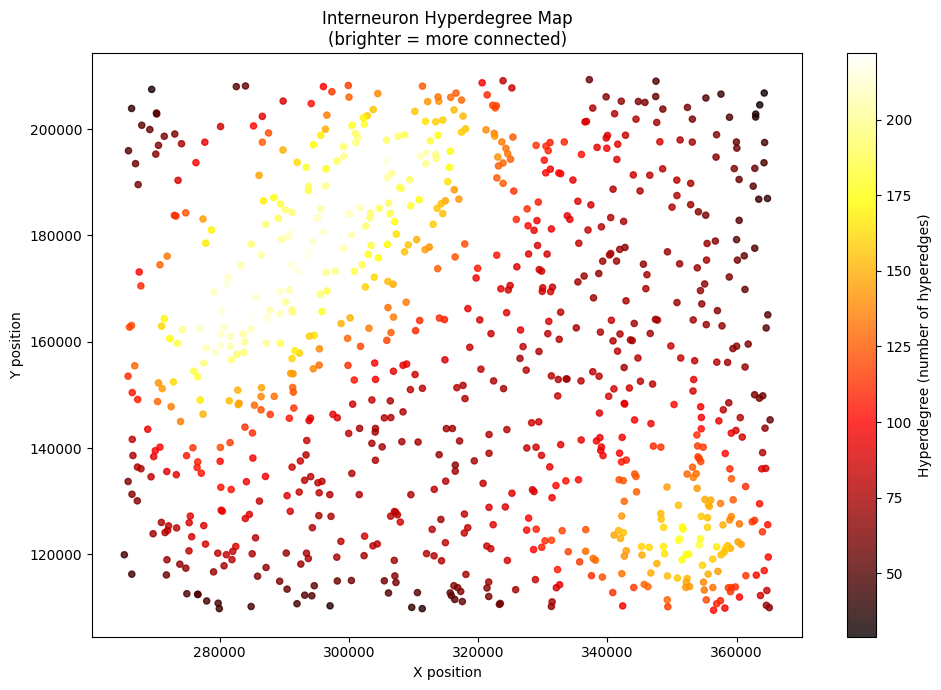

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import matplotlib.pyplot as plt

# Add degree info back to patch
patch = patch.copy()
patch['hyperdegree'] = patch.index.map(lambda x: node_degree.get(x, 0))

inter_patch = patch[patch['celltype'] == 'INTERNEURON']

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    inter_patch['x'], inter_patch['y'],
    c=inter_patch['hyperdegree'],
    cmap='hot', s=20, alpha=0.8
)
plt.colorbar(scatter, label='Hyperdegree (number of hyperedges)')
plt.title('Interneuron Hyperdegree Map\n(brighter = more connected)')
plt.xlabel('X position')
plt.ylabel('Y position')
plt.tight_layout()
plt.show()

HIGH connectivity interneurons (top 25%):
layer
Layer 4    163
Layer 2     39
Layer 3      7
Name: count, dtype: int64
Average position - x: 308170, y: 166267

LOW connectivity interneurons (bottom 25%):
layer
Layer 3    198
Layer 5     16
Layer 4      9
Layer 2      5
Name: count, dtype: int64
Average position - x: 323232, y: 155592


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


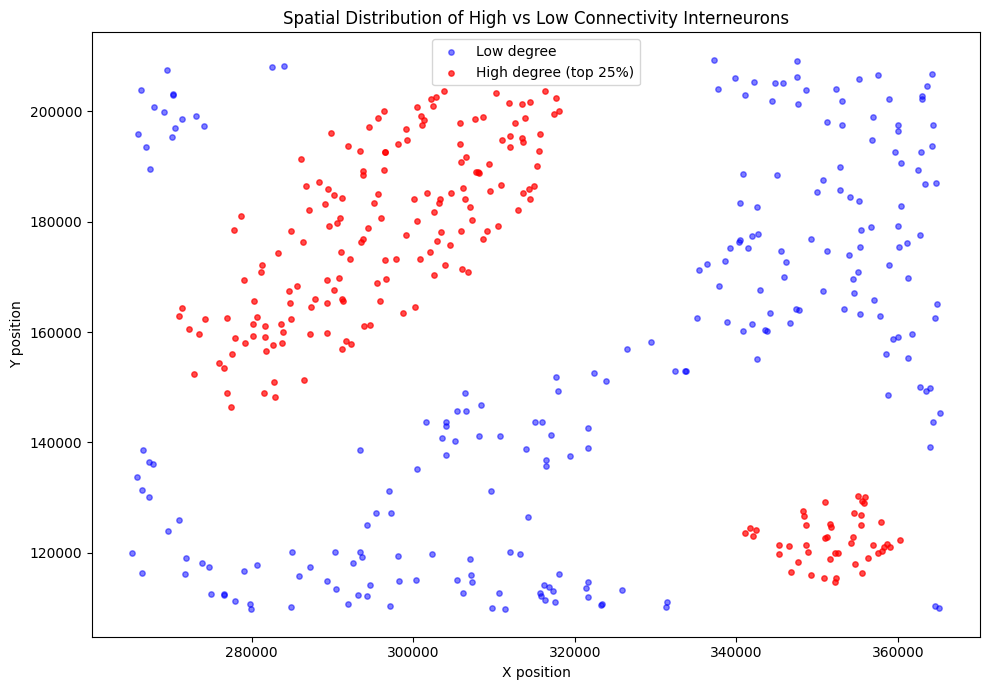

In [ ]:
# Let's see if the high-degree interneurons cluster in specific layers
high_degree = inter_patch[inter_patch['hyperdegree'] > inter_patch['hyperdegree'].quantile(0.75)]
low_degree = inter_patch[inter_patch['hyperdegree'] <= inter_patch['hyperdegree'].quantile(0.25)]

print("HIGH connectivity interneurons (top 25%):")
print(high_degree['layer'].value_counts())
print(f"Average position - x: {high_degree['x'].mean():.0f}, y: {high_degree['y'].mean():.0f}")

print("\nLOW connectivity interneurons (bottom 25%):")
print(low_degree['layer'].value_counts())
print(f"Average position - x: {low_degree['x'].mean():.0f}, y: {low_degree['y'].mean():.0f}")

# Plot high vs low degree spatially
plt.figure(figsize=(10, 7))
plt.scatter(low_degree['x'], low_degree['y'], c='blue', s=15, alpha=0.5, label='Low degree')
plt.scatter(high_degree['x'], high_degree['y'], c='red', s=15, alpha=0.7, label='High degree (top 25%)')
plt.title('Spatial Distribution of High vs Low Connectivity Interneurons')
plt.xlabel('X position')
plt.ylabel('Y position')
plt.legend()
plt.tight_layout()
plt.show()

**Checkpoint:** run the cell below after finishing this notebook so `02_Single_Patch_Fitting` can restore this state.

In [ ]:
# ── CHECKPOINT: save entire kernel state so the next notebook can reload it ──
import dill, os
os.makedirs("checkpoints", exist_ok=True)
dill.dump_session("checkpoints/01_state.pkl")
print("Saved checkpoint: checkpoints/01_state.pkl")